# Utforske data


In [1]:
import os
import random
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight
import kagglehub

/opt/anaconda3/envs/dat255/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
#Laster ned datasettet
dataset_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
# Definerer hovedmappe for data
data_path = os.path.join(dataset_path, "Data")

#Lager paths til de forskjellige datasettene
train_path = os.path.join(data_path, "train")
valid_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

#Se innholdet i mappene
print("Data path:", data_path)
print()
print("TRAIN:", os.listdir(train_path))
print("VALID:", os.listdir(valid_path))
print("TEST:", os.listdir(test_path))

Data path: /Users/christoffertoftevag/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1/Data

TRAIN: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
VALID: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']
TEST: ['squamous.cell.carcinoma', 'large.cell.carcinoma', 'adenocarcinoma', 'normal']


### OBS

Datasettet er inkonsistent. Train og Valid har like navn, men Testsettet har en forkortelse på navnene.

In [4]:
# Definerer en fast og konsistent rekkefølge på klassene

long_class_names = [
    "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
]

print(long_class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [5]:
#Mapper kort til langt navn slik at alle datasettene bruker likt navn!
test_to_train_name_map = {
    "adenocarcinoma": "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib",
    "large.cell.carcinoma": "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "normal": "normal",
    "squamous.cell.carcinoma": "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
}

In [6]:
#lager path til ny mappe
test_fixed_path = os.path.join(data_path, "test_fixed")

#sletter mappen hvis den finnes fra før
if os.path.exists(test_fixed_path):
    shutil.rmtree(test_fixed_path)

#lager ny tom mappe
os.makedirs(test_fixed_path)


#looper gjennom mappingen vi lagde over
for short_name, long_name in test_to_train_name_map.items():
    #lager paths til source og destination
    src = os.path.join(test_path, short_name)
    dst = os.path.join(test_fixed_path, long_name)
    shutil.copytree(src, dst)

#nå skal alle dataene ha samme (lange) navn
print("Ny testnavn:", os.listdir(test_fixed_path))

Ny testnavn: ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']


In [7]:


img_size = (128, 128)
batch_size = 32


train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    #klassene blir tall
    label_mode="int",
    #slik at vi har full kontroll over rekkefølgen av klassene i alle datasettene
    class_names=long_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=SEED
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_fixed_path,
    labels="inferred",
    label_mode="int",
    class_names=long_class_names,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


2026-04-22 08:12:12.087374: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-22 08:12:12.087409: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-22 08:12:12.087418: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-22 08:12:12.087434: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-22 08:12:12.087445: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
print("Train classes:", train_data.class_names)
print("Valid classes:", valid_data.class_names)
print("Test classes:", test_data.class_names)

Train classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [9]:
#gjør om pikselverdi fra 0-255 -> 0-1
#(modellen lærer mye bedre med små verdier!)
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
#normaliser hvert bildet og behold label
train_data = train_data.map(lambda img, label: (normalization_layer(img), label))
valid_data = valid_data.map(lambda img, label: (normalization_layer(img), label))
test_data = test_data.map(lambda img, label: (normalization_layer(img), label))

In [10]:
train_data = train_data.prefetch(tf.data.AUTOTUNE)
valid_data = valid_data.prefetch(tf.data.AUTOTUNE)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

In [11]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
First 10 labels: [3 1 3 2 3 0 0 0 0 3]


2026-04-22 08:12:12.271161: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


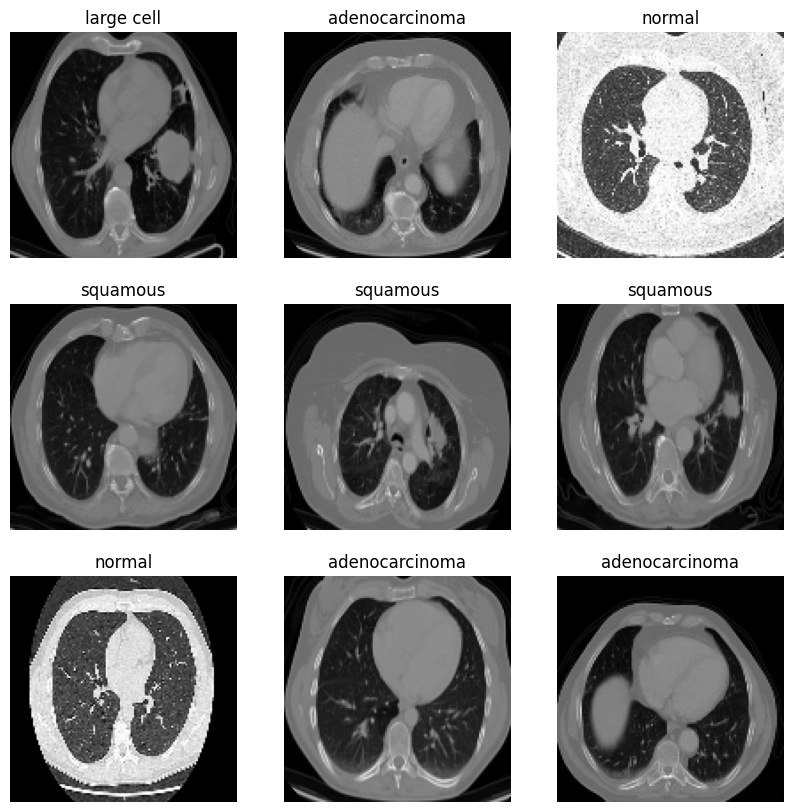

2026-04-22 08:12:12.549105: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
#navnene er veldig lange -> plottene ser dårlig ut
#lager forkortelser
display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(display_names[labels[i]])
        plt.axis("off")
    plt.show()

In [13]:
#vise klassefordeling
def count_images_per_class(folder_path):
    counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            counts[class_name] = len(os.listdir(class_folder))
    return counts

print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma': 90, 'large.cell.carcinoma': 51, 'adenocarcinoma': 120, 'normal': 54}


In [14]:
def get_true_and_pred(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_labels = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_labels)

    return np.array(y_true), np.array(y_pred)

In [15]:
def evaluate_model(model, dataset, model_name="Model", print_report=True):
    y_true, y_pred = get_true_and_pred(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

    if print_report:
        print(f"=== {model_name} ===")
        print(json.dumps(results, indent=2))
        print("\nClassification report:")
        print(classification_report(y_true, y_pred, target_names=display_names, zero_division=0))

    return results, y_true, y_pred

In [16]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
    disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [17]:
def plot_history(history, title_prefix="Model"):
    train_acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc, label="Train accuracy")
    plt.plot(epochs, val_acc, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Training vs Validation Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Training vs Validation Loss")
    plt.legend()
    plt.show()

Modellering
--

Commonsense baseline
--

Vi ville ha en baseline modell som vi kan prøve å forbedre med mer avanserte modelle. Vi bruker en majoritetsklasse-modell som alltid predikerer den mest vanlige klassen i treningssettet. I koden over kan vi se at adenocarcinoma er den største klassen i treningsdata. I koden under kan vi se at adenocarcinoma er i index 0, vi kan bruke dette til å se hvilke accuracy vi kan få hvis vi kun tipper adenocarcinoma. Med denne "commonsense" modellen får vi en baseline på 38% accuracy.

2026-04-22 08:12:12.697801: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Baseline validation accuracy: 0.3194444444444444
                precision    recall  f1-score   support

adenocarcinoma       0.32      1.00      0.48        23
    large cell       0.00      0.00      0.00        21
        normal       0.00      0.00      0.00        13
      squamous       0.00      0.00      0.00        15

      accuracy                           0.32        72
     macro avg       0.08      0.25      0.12        72
  weighted avg       0.10      0.32      0.15        72



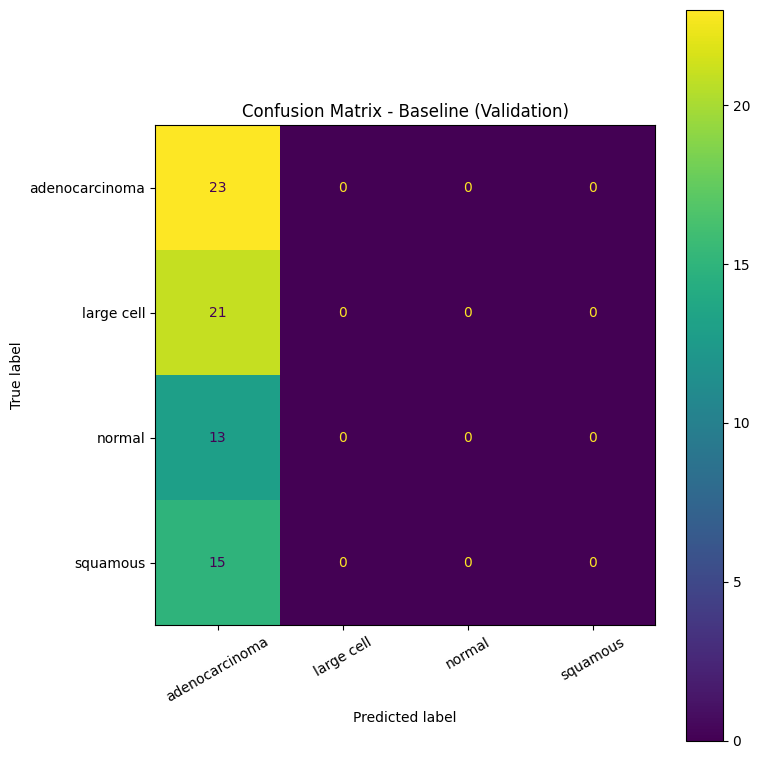

In [18]:
#model0
#over kan vi se at klasse 0 er adenocarcinoma.
majority_class = 0

labels_true = []

for img, label in valid_data:
    labels_true.extend(label.numpy())

labels_true = np.array(labels_true)
labels_pred = np.full_like(labels_true, fill_value=majority_class)

print("Baseline validation accuracy:", accuracy_score(labels_true, labels_pred))
print(classification_report(labels_true, labels_pred, target_names=display_names, zero_division=0))
plot_confusion(labels_true, labels_pred, "Confusion Matrix - Baseline (Validation)")

Simple dens layer neural network
--

In [19]:
#model1
ff_network = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

ff_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

ff_network summaty:
--
flatten: gjør vår input 128 * 128 * 3 om til en lang liset med tall = 49152.
første dense laget: (input_features × neurons) + bias = 3,145,792
andre dense laget: 64 * 16 + 16 = 1,040
siste dense laget: 16 * 4 + 4 = 68

In [20]:
ff_network.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [21]:
history_ff = ff_network.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10


2026-04-22 08:12:13.059581: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3703 - loss: 58.4124 - val_accuracy: 0.3194 - val_loss: 84.7268
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4192 - loss: 32.6064 - val_accuracy: 0.3750 - val_loss: 30.9128
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4698 - loss: 10.0839 - val_accuracy: 0.3611 - val_loss: 5.9810
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5432 - loss: 4.3439 - val_accuracy: 0.3889 - val_loss: 3.4971
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5710 - loss: 3.6199 - val_accuracy: 0.3889 - val_loss: 3.8536
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5905 - loss: 3.3801 - val_accuracy: 0.5000 - val_loss: 3.6519
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6085 - loss: 3.0812 - val_accuracy: 0.4306 - val_loss: 3.9842
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6117 - loss: 2.8022 - val_accuracy: 0.4306 - val_los

In [22]:
score = ff_network.evaluate(valid_data, verbose=0)

print("loss:", score[0])
print("Accuracy of the model was {}%".format(score[1]*100))

loss: 2.7276902198791504
Accuracy of the model was 55.55555820465088%


=== Improved CNN - validation ===
{
  "model": "Improved CNN - validation",
  "accuracy": 0.5555555555555556,
  "precision_macro": 0.5678571428571428,
  "recall_macro": 0.5563306258958433,
  "f1_macro": 0.5480175864040535,
  "f1_weighted": 0.5488456457877408
}

Classification report:
                precision    recall  f1-score   support

adenocarcinoma       0.53      0.70      0.60        23
    large cell       0.67      0.38      0.48        21
        normal       0.50      0.62      0.55        13
      squamous       0.57      0.53      0.55        15

      accuracy                           0.56        72
     macro avg       0.57      0.56      0.55        72
  weighted avg       0.57      0.56      0.55        72



2026-04-22 08:12:18.015302: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


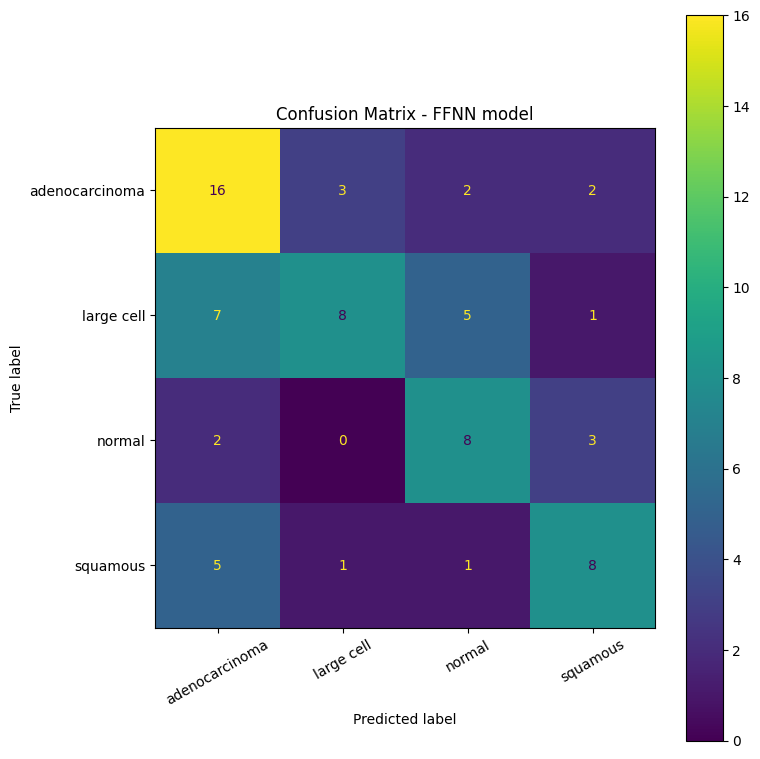

In [23]:
ff_results, label_true_val_1, label_pred_val_1 = evaluate_model(
    ff_network,
    valid_data,
    model_name="Improved CNN - validation"
)

plot_confusion(label_true_val_1, label_pred_val_1, "Confusion Matrix - FFNN model")

Vi kan tydlig se at modellen vår ikke er god nok. Vi kan videre undersøke hvordan modellen fungerer.

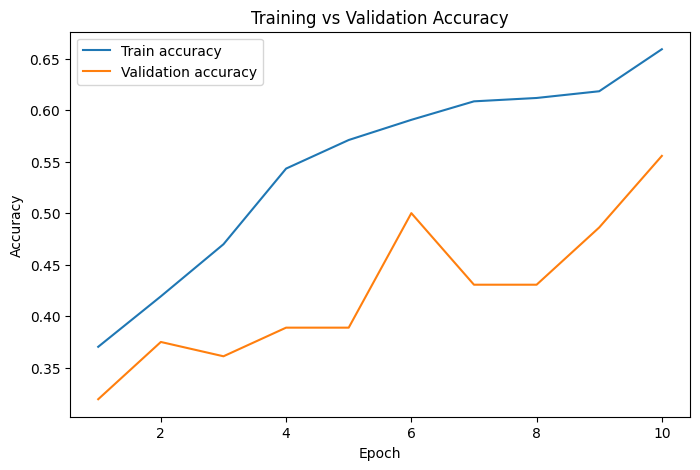

In [24]:
import matplotlib.pyplot as plt

train_acc = history_ff.history["accuracy"]
val_acc = history_ff.history["val_accuracy"]
train_loss = history_ff.history["loss"]
val_loss = history_ff.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

Tolkning av graf
--


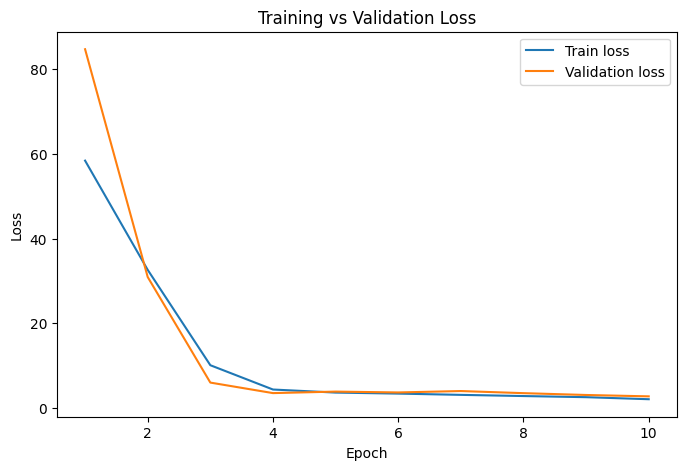

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Modellen lærer veldig fort mellom epoche 1 - 3.
mellom epoche 2-4 ligger kruvene veldig nær hverandre. modellen generaliserer bra. 
Epoche 7-10 begynner validationloss å flate ut også stige litt. Trainingloss fortsetter ganske flatt, dette kan tyde på overfitting.

Tolkning av Confusion Matrix
--
Modellen hadde totalt 8+5+50+60 = 123 riktige predikasjoner av totalt 310 observasjoner. Dette betyr en accuracy på 123/310 = 40%, dette bekrefter at modellen presterer svakt sammenlignet med vår baseline på 38%.

Ved nærmere analyse av confusion matrixen ser vi tydlige svakheter i klassifiseringen av enkelte klasser. Spesielt gjelder dette adenocarcinoma, hvor modellen kun klassifiserte 8 riktige av 120 tilfeller, og 80 tilfeller ble klassifisert som squamous og 32 som normal. Detter viser at modellen i litne grad klarer å skille adenocarcinoma fra de andre klassene.

Modellen klarer i nesten alle tilfeller å predikerer normal, med 50 riktige av 54 tillfeller, og modellen gjøre det relativt greit på aquamous med 60 riktige. Dette tyder på en skjevhet (bias) i modellen hvor den har en tendens til å velge disse klassene.

En slik bias er spesielt problematisk i en medisinsk kontekst, hvor det innebærer at kreftseller blir i noen tilfeller klassifisert som normal

Vi kan se om datasettet kan være en av grunnene for at modellen gjør det så dårlig:

In [26]:
print("Train:", count_images_per_class(train_path))
print("Valid:", count_images_per_class(valid_path))
print("Test:", count_images_per_class(test_path))

Train: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 155, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 195, 'normal': 148, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 115}
Valid: {'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 15, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 23, 'normal': 13, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 21}
Test: {'squamous.cell.carcinoma': 90, 'large.cell.carcinoma': 51, 'adenocarcinoma': 120, 'normal': 54}


Vi kan tydlig se at large cell er den klassen med minst treningssamples. Dette kan forklare grunnen for at modellen ikke klarer å lære gode mønstre for denne klassen. 
Samtidig ser vi at testsettet inneholder 120 tilfeller av adenocarcinoma, men modellen klarer kun å klassifisere 8 riktig. Dette kan tyde på at datasettet ikke er det eneste problemet, men at modellen ikke klarer å fange opp mønstre i dataen. Dette er forventet i en feedforward modell som ser bilder som en flatten liste med tall.

Data agumentation and rescaling
--
Vi kan prøve å fikse problemet med lite data ved hjelp av agumentation:

In [27]:
#model2

data_augmentation_ff = tf.keras.Sequential([
    #tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.2)
])

# Enkel dense-modell med augmentation
ff_network_aug = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation_ff,

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])


ff_network_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,146,900 (12.00 MB)

 Trainable params: 3,146,900 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
ff_network_aug.compile(
    loss="sparse_categorical_crossentropy", 
    optimizer="adam",
    metrics=["accuracy"]
)

In [29]:
history_ff_aug = ff_network_aug.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.2594 - loss: 57.7445 - val_accuracy: 0.3472 - val_loss: 26.7689
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2529 - loss: 80.6961 - val_accuracy: 0.3611 - val_loss: 21.0178
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2773 - loss: 81.0841 - val_accuracy: 0.3889 - val_loss: 36.7088
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2822 - loss: 77.2620 - val_accuracy: 0.4306 - val_loss: 30.7534
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2773 - loss: 74.8425 - val_accuracy: 0.3889 - val_loss: 28.2125
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2936 - loss: 79.4988 - val_accuracy: 0.4583 - val_loss: 27.0196
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3116 - loss: 71.6919 - val_accuracy: 0.3611 - val_loss: 40.0979
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3051 - loss: 73.4655 - val_accur

In [30]:
score = ff_network_aug.evaluate(valid_data, verbose=0)

print("Valid loss:", score[0])
print("Valid accuracy:", score[1])

Valid loss: 20.843358993530273
Valid accuracy: 0.4166666567325592


Konklusjon av FFNN:
--
Med omfattende testing og analyse ser vi at resultatene fra FFNN-modelen ikke er pålitlige nok til å kunne trekke en konklusjon. Modellen er for enkel, og datasettet er for lite til at modellen kunne lære mønstre. Vi observerte også stor variasjon (+- 15%) mellom kjøring av samme kode på forskjellige seed, noe som tyder på at en mer avanser modell må tas i bruk.

Prøver en CNN modell
--

In [31]:
#model3
simple_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [32]:
simple_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_simple_cnn = simple_cnn_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15,
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3018 - loss: 1.3528 - val_accuracy: 0.1806 - val_loss: 1.3647
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3670 - loss: 1.2425 - val_accuracy: 0.3056 - val_loss: 1.2661
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4584 - loss: 1.1540 - val_accuracy: 0.5000 - val_loss: 1.1121
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4959 - loss: 1.0787 - val_accuracy: 0.5000 - val_loss: 1.1202
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5204 - loss: 1.0400 - val_accuracy: 0.5000 - val_loss: 1.0714
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5008 - loss: 1.0525 - val_accuracy: 0.5000 - val_loss: 1.0114
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4878 - loss: 1.1124 - val_accuracy: 0.4861 - val_loss: 1.0281
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5024 - loss: 1.0597 - val_accuracy: 0.5000 - v

In [34]:
valid_loss, valid_acc = simple_cnn_model.evaluate(valid_data, verbose=0)

print("Test loss:", valid_loss)
print("Test accuracy:", valid_acc)

Test loss: 0.9776577353477478
Test accuracy: 0.4722222089767456


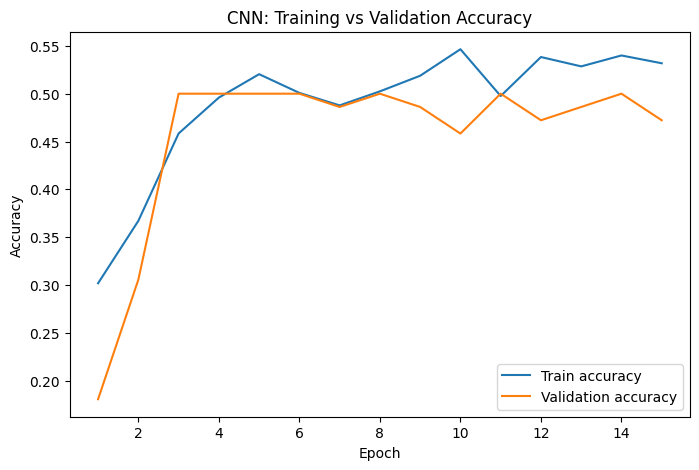

In [35]:
import matplotlib.pyplot as plt

train_acc = history_simple_cnn.history["accuracy"]
val_acc = history_simple_cnn.history["val_accuracy"]
train_loss = history_simple_cnn.history["loss"]
val_loss = history_simple_cnn.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

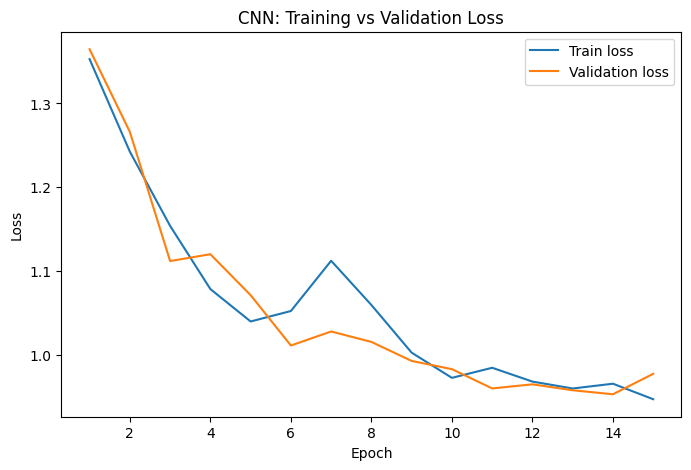

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Train accuracy går opp, noe som viser at modellen lærer. modellen finner mønster i data. Modellen er robust, validation holder seg stabil. Vi ser ingen tegn til overfitting, og det er bra generelt, men vi vil først ha en modell som overfitter for å deretter endre modellen til at den ikke overfitter.

Vi kan endre modellen slik at den overfitter:

In [37]:
#model4
#vi lager en større modell og øker epokene:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,228 (1.54 MB)

 Trainable params: 404,228 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history_cnn = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20,
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.2741 - loss: 1.3438 - val_accuracy: 0.2083 - val_loss: 1.3062
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4274 - loss: 1.1953 - val_accuracy: 0.5000 - val_loss: 1.1525
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4747 - loss: 1.1161 - val_accuracy: 0.4861 - val_loss: 1.0804
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5139 - loss: 1.0745 - val_accuracy: 0.5000 - val_loss: 1.0872
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4959 - loss: 1.0937 - val_accuracy: 0.5000 - val_loss: 1.0282
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5285 - loss: 1.0221 - val_accuracy: 0.3472 - val_loss: 1.0550
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.4600 - loss: 1.0749 - val_accuracy: 0.4028 - val_loss: 1.0604
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.5693 - loss: 0.9862 - val_accuracy: 0.4722 - v

In [40]:
valid_loss, val_acc = model.evaluate(valid_data, verbose=0)

print("Val loss:", valid_loss)
print("Val accuracy:", valid_acc)

Val loss: 0.95229572057724
Val accuracy: 0.4722222089767456


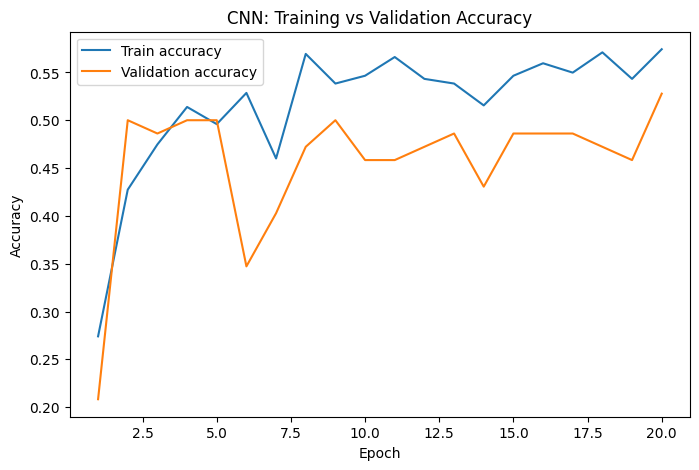

In [41]:
import matplotlib.pyplot as plt

train_acc = history_cnn.history["accuracy"]
val_acc = history_cnn.history["val_accuracy"]
train_loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

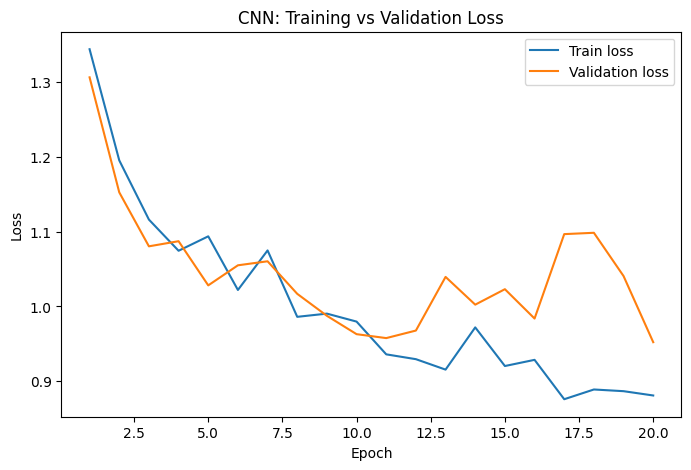

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

Tolkning av graf
--
Vi kan se at traing accuract går jevnt opp, dette tyder på at modellen lærer. Train accuracy er er over validation accuracy store deler av epokene, noe som tyder på mild overfitting. dette er bra, det var det vi ville oppnå. Begge loss minker, men etter epoke 16 øker validation loss. Dette kan være et tegn på at overfitting begynner. Ut i fra det vi har tolket fra grafene, kan vi lage en forbedret modell

Forbedring:
Vi kan legge til data augmentation. Grafene viser at modellen lærte treningsdata bedre enne valideringsdata. det kan tyde på at modellen begynte å bli for god på treningssettet, da vil augmentation hjelpe med å modellen flere varianter av samme bilde, redusere overfitting og gjøre modellen mer robust. 
Modellen var ganske kraftig med 64 - 128 - 256, vi kan endre dette til 32 - 64 - 128. det er ingenting i grafene som tilsier at modellen er for krafig, så vi kan gjøre den litt mindre. Det vil da føre til at det blir lettere å generalisere på et lite datasett og reduserer overfitting. 
Vi kan legge til padding="same" for å bevare mer informasjon i feature maps.
Vi kan minke litt på dropout. 
Vi kan legge til early stopping. Grafene viser at validation accuracy flater ut ganske tidlig, og validation loss begynner å øke senere, dette tyder på at modellen er best før siste epoke, noe som vi kan fiske med early stopping, som vil stoppe treningen når modellen slutter å bli bedre.
Merk: vi kunne også lagt til cross-validation for å få en mer robust evaluering, men ble ikke brukt siden datasettet hadde en fast test/train/validation - inndeling.

In [43]:
#model5

data_augmentation = tf.keras.Sequential([
    #tf.keras.layers.RandomFlip("horizontal"),
    #tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(4, activation="softmax")
])

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [45]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [46]:
history_cnn = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=25,
    callbacks=[early_stopping]
)

model.summary()

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.2985 - loss: 1.3492 - val_accuracy: 0.1806 - val_loss: 1.4777
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3197 - loss: 1.3286 - val_accuracy: 0.1806 - val_loss: 1.4425
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.3556 - loss: 1.2710 - val_accuracy: 0.1944 - val_loss: 1.5151
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.4731 - loss: 1.2009 - val_accuracy: 0.4861 - val_loss: 1.1732
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5432 - loss: 1.0912 - val_accuracy: 0.4583 - val_loss: 1.1448
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4959 - loss: 1.0337 - val_accuracy: 0.5139 - val_loss: 1.1233
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5041 - loss: 1.0860 - val_accuracy: 0.4167 - val_loss: 1.0099
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5710 - loss: 0.9988 - val_accuracy: 0.4861 - v

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,294 (1.16 MB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,530 (795.04 KB)

In [47]:
valid_loss, valid_acc = model.evaluate(valid_data, verbose=0)

print("Val loss:", valid_loss)
print("Val accuracy:", valid_acc)

Val loss: 0.9588253498077393
Val accuracy: 0.5


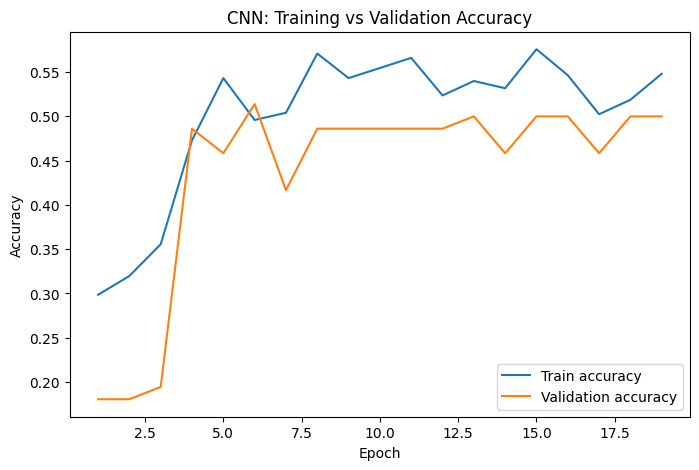

In [48]:
import matplotlib.pyplot as plt

train_acc = history_cnn.history["accuracy"]
val_acc = history_cnn.history["val_accuracy"]
train_loss = history_cnn.history["loss"]
val_loss = history_cnn.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Train accuracy")
plt.plot(epochs, val_acc, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN: Training vs Validation Accuracy")
plt.legend()
plt.show()

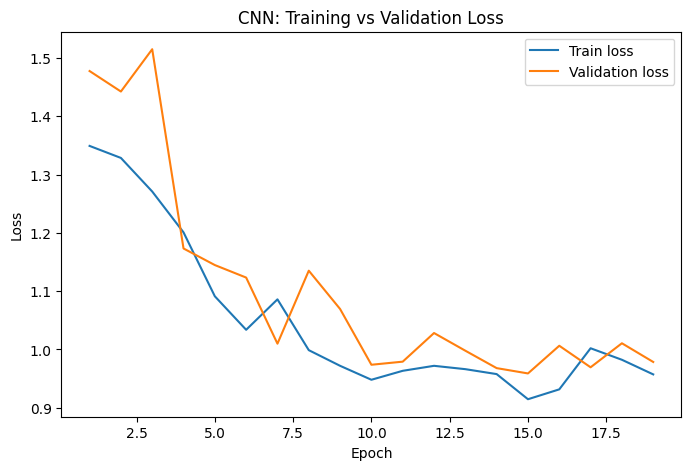

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN: Training vs Validation Loss")
plt.legend()
plt.show()

2026-04-22 08:13:23.879477: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


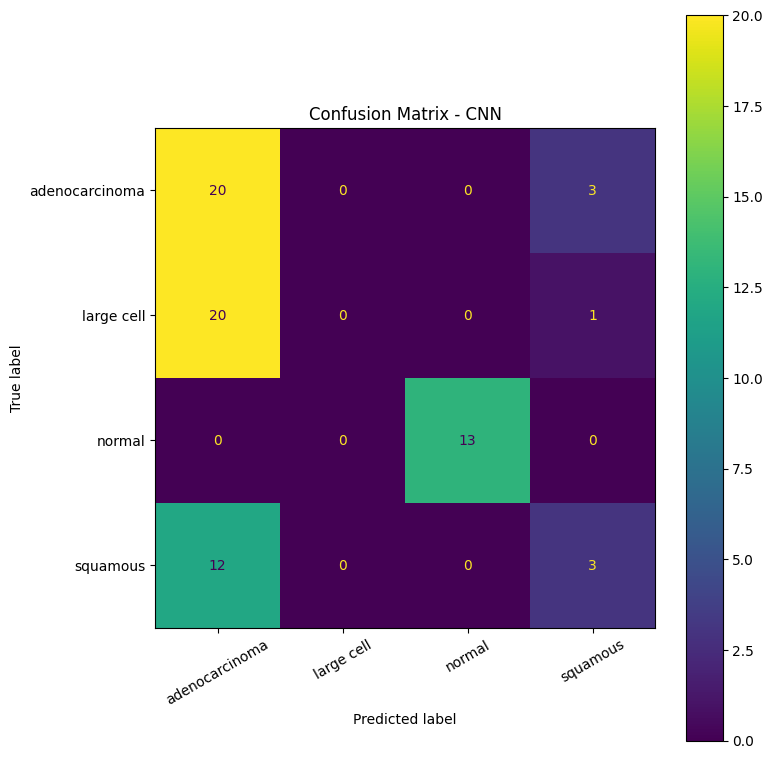

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in valid_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

display_names = [
    "adenocarcinoma",
    "large cell",
    "normal",
    "squamous"
]

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)

plt.title("Confusion Matrix - CNN")
plt.tight_layout()
plt.show()

Tolkning av Confusion Matrix
--
Confusion matrixen viser en tydelig skjevhet i predikasjonene, hvor nesten alle tilfellene klassifiseres som adenocarcinoma. Dette fører til at klasser som large cell og squamous nesten aldri blir riktig klassifisert.

Selv om denne modellen har fått klart høyes accuracy, skjuler dne et alvorlig problem hvor modellen ikke klarer å skille mellom flere av klassene. Dette viser at accuracy alene ikke er bra nok som evalueringsmetode.

Forbedring av modellen:
Confusion matrixen viste at modellen hadde en sterk bias mot adenocarcinoma, og at den i liten grad klarte å klassifisere riktig large cell og squamous. For å fikse dette kan vi legge til weights til klassene, slik at feil på underrepresenterte klasser ble straffet hardere under trening. I tillegg legger vi til batch og normalization for å stabilisere læringen og forbedre feature extraction. ReduceLROnPlateau og EarlyStopping brukt for å forbedre treningsstabilitet og generalisering


Transfer learning
--

In [51]:
# model5

data_augmentation_tl = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.1)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

pretrained_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    data_augmentation_tl,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation="softmax")
])

pretrained_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

pretrained_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,228 (8.93 MB)

 Trainable params: 82,244 (321.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [52]:
history_pretrained = pretrained_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.4209 - loss: 1.7032 - val_accuracy: 0.5694 - val_loss: 1.0031
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5400 - loss: 1.4434 - val_accuracy: 0.4861 - val_loss: 1.2702
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5579 - loss: 1.3662 - val_accuracy: 0.5139 - val_loss: 1.3490
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6003 - loss: 1.3098 - val_accuracy: 0.5556 - val_loss: 1.6261
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6101 - loss: 1.3100 - val_accuracy: 0.5278 - val_loss: 1.1841
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6085 - loss: 1.2111 - val_accuracy: 0.5833 - val_loss: 1.0300
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6330 - loss: 1.1480 - val_accuracy: 0.5972 - val_loss: 0.9789
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6460 - loss: 1.1670 - val_accuracy: 0.6111 - 

In [53]:
score = pretrained_model.evaluate(valid_data, verbose=0)

print("Valid loss:", score[0])
print("Valid accuracy:", score[1])

Valid loss: 1.1763570308685303
Valid accuracy: 0.5972222089767456


2026-04-22 08:14:19.351481: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


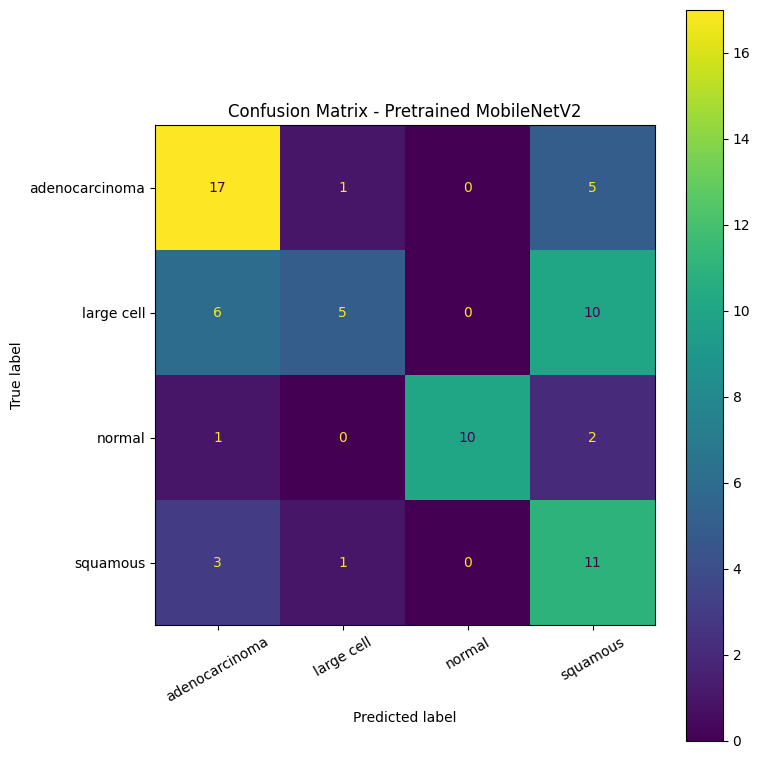

In [55]:
y_true = []
y_pred = []

for images, labels in valid_data:
    predictions = pretrained_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(ax=ax, cmap="viridis", xticks_rotation=30, colorbar=True)

plt.title("Confusion Matrix - Pretrained MobileNetV2")
plt.tight_layout()
plt.show()